In [24]:
#Verileri işlemek için gerekli kütüphaneler
import pandas as pd
import numpy as np

#Verilerin grafiğini çizdirmek için gerekli kütüphane
import matplotlib.pyplot as plt

#Denetimli Öğrenmede kullandığım Lineer Regresyon
from sklearn.linear_model import LinearRegression

#Random Forest Algoritmasını da ekliyorum Lineer Regresyon ile karşılaştırmak için
from sklearn.ensemble import RandomForestRegressor

#İyi sonuçlar almak için kullandığım performans metrikleri
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
dosya = "NVDA.csv"
df = pd.read_csv(dosya)

print("Son 5 Satır:")
print(df.tail())
print("\n Sütunlar:")
print(df.columns)

Son 5 Satır:
            Date   Adj Close       Close        High         Low        Open  \
6553  2025-02-10  133.570007  133.570007  135.000000  129.960007  130.089996   
6554  2025-02-11  132.800003  132.800003  134.479996  131.020004  132.580002   
6555  2025-02-12  131.139999  131.139999  132.240005  129.080002  130.020004   
6556  2025-02-13  135.289993  135.289993  136.500000  131.169998  131.559998   
6557  2025-02-14  138.850006  138.850006  139.250000  135.500000  136.479996   

         Volume  
6553  216989100  
6554  178902400  
6555  160278600  
6556  197430000  
6557  194892300  

 Sütunlar:
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


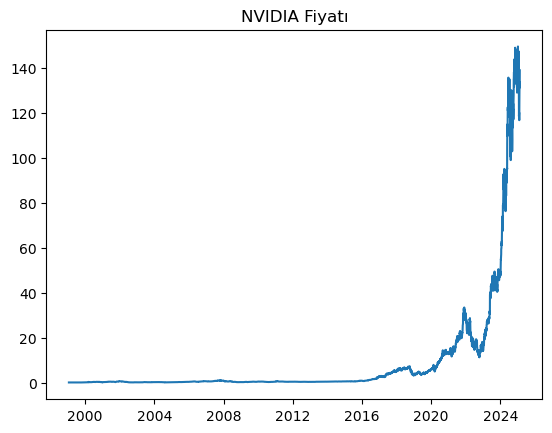

In [26]:
#Tarihi düzgün çevirmek için
df["Date"] = pd.to_datetime(df["Date"])
#Tarihe göre sıralamak için
df = df.sort_values("Date").reset_index(drop=True)

#Grafik Çizdirme
plt.plot(df['Date'], df['Close'])
plt.title('NVIDIA Fiyatı')
plt.show()

In [27]:
#Değişkenleri tanımlama
degerler = ["Close", "High", "Low", "Volume"]
#Bir sonraki günün kapanış fiyatını tahmin edeceğiz
X = df[degerler]
y = df["Close"].shift(-1)
#Son satırda yarının verisi yok, NaN oluşuyor. O yüzden çıkarıyoruz
X = X.iloc[:-1]
y = y.iloc[:-1]

In [28]:
# Veriyi %80 eğitim %20 test olarak ayırıyoruz
ayirma_yeri = int(len(df) * 0.80)

X_train = X.iloc[:ayirma_yeri]
X_test = X.iloc[ayirma_yeri:]
y_train = y.iloc[:ayirma_yeri]
y_test = y.iloc[ayirma_yeri:]

LR MAE: 0.9900751261247943
LR RMSE: 1.9142342249704187
LR R2: 0.9977464194163755

Yarının tahmini: [135.02170081]


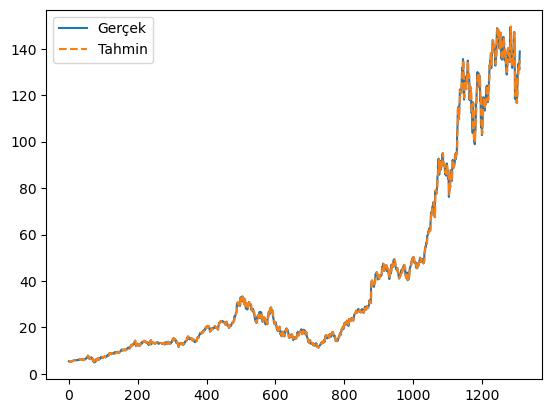

In [44]:
# Lineer Regresyon modelini oluşturma
lin_reg_model = LinearRegression()

# Modeli eğitim verisiyle eğitme
lin_reg_model.fit(X_train, y_train)

# Test verisi ile tahmin
y_pred = lin_reg_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("LR MAE:", mean_absolute_error(y_test, y_pred))
print("LR RMSE:", rmse)
print("LR R2:", r2)

# En son günün verileriyle yarının tahmini
son_gun = X.iloc[-1:]
yarin_tahmini = lin_reg_model.predict(son_gun)

print(f"\nYarının tahmini: {yarin_tahmini}")

#Grafik Çizdirme
plt.plot(y_test.values, label='Gerçek')
plt.plot(y_pred, label='Tahmin', linestyle='--')
plt.legend()
plt.show()

In [40]:
#Random Forest Modelini oluşturma
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=33
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_rf)

RF MAE: 33.04127247804233
RF RMSE: 52.081451048259495
RF R2: -0.6682037377589731


In [41]:
#Aldığımız sonuçlara göre hangi model başarılı diye çıktı alalım
print("\nSonuç:")
if r2 > r2_rf:
    print("Lineer Regresyon daha iyi sonuç verdi!")
else:
    print("Random Forest daha iyi sonuç verdi!")


Sonuç:
Lineer Regresyon daha iyi sonuç verdi!
